In [1]:
#import libraries
import numpy as np
import statistics
import matplotlib.pyplot as plt

In [2]:
"""As a baseline, generate 15 Fibonacci numbers as "stock" and explain in 3–5 
sentences why unbounded Fibonacci growth is biologically unrealistic."""
fibonacci = [0, 1]
while len(fibonacci) < 15:
    fibonacci.append(fibonacci[-1] + fibonacci[-2])

print("Fibonacci stock:")
print(fibonacci)

Fibonacci stock:
[0, 1, 1, 2, 3, 5, 8, 13, 21, 34, 55, 89, 144, 233, 377]


In [3]:
"""Implement a FishStock class using the discrete logistic growth model with 
harvesting: N(t+1) = N(t) + r·N(t)·(1 − N(t)/K) − h·N(t). Use r = 0.4, K = 10,000 
tonnes, N(0) = 4,000 tonnes and simulate 52 weeks."""
import numpy as np
class FishStock:
    def __init__(self, r=0.4, K=10000, N0=4000, h=0.10):
        self.r = r
        self.K = K
        self.N0 = N0
        self.h = h

    def simulate(self, weeks=52):
        stock = [self.N0]
        harvest = []

        for week in range(weeks):
            N = stock[-1]
            H = self.h * N
            harvest.append(H)
            next_N = (N + self.r * N * (1 - N / self.K)- self.h * N)
            next_N = max(0, next_N)
            stock.append(next_N)

        return np.array(stock), np.array(harvest)

In [4]:
#test the model
fish = FishStock(h=0.10)
stock, harvest = fish.simulate(weeks=52)
print("Initial stock:", stock[0], "tonnes")
print("Final stock:", stock[-1], "tonnes")
print("Total harvested:", harvest.sum(), "tonnes")

Initial stock: 4000.0 tonnes
Final stock: 7499.999925392722 tonnes
Total harvested: 37362.5084681044 tonnes


In [5]:
"""Implement a PriceModel class that simulates the weekly price in UGX/kg as a 
seeded random walk starting at 12,000, with bounds (e.g. 9,000–16,000). Weekly 
revenue = harvest (kg) × price."""
class PriceModel:
    def __init__(self,start=12000,lower=9000,upper=16000,seed=42,step_sd=300):
        self.start = start
        self.lower = lower
        self.upper = upper
        self.seed = seed
        self.step_sd = step_sd

    def simulate(self, weeks=52):
        rng = np.random.default_rng(self.seed)
        prices = [self.start]
        for week in range(weeks - 1):
            change = rng.normal(0, self.step_sd)
            new_price = prices[-1] + change
            new_price = np.clip(new_price,self.lower,self.upper)
            prices.append(new_price)
        return np.array(prices)

In [6]:
#generate the prices
price_model = PriceModel(seed=42)
prices = price_model.simulate(52)
print("First 10 weekly prices:")
print(prices[:10])

First 10 weekly prices:
[12000.         12091.41512393 11779.41989205 12004.5552508
 12286.72466571 11701.41410912 11310.76025706 11349.11237801
 11254.23960031 11249.19925305]


In [7]:
#weekly revenue
#1 tonne = 1,000 kg
weekly_revenue = harvest * 1000 * prices
print(weekly_revenue)

[4.80000000e+09 5.51368530e+09 6.00309393e+09 6.70605643e+09
 7.38909589e+09 7.45541399e+09 7.53185064e+09 7.81161583e+09
 7.93748782e+09 8.07582756e+09 7.99343382e+09 8.26017489e+09
 8.48611405e+09 8.53972246e+09 8.81902061e+09 8.94368723e+09
 8.76533781e+09 8.85790176e+09 8.64950081e+09 8.85165557e+09
 8.84384297e+09 8.80466178e+09 8.65318409e+09 8.92931594e+09
 8.89538155e+09 8.79959931e+09 8.72077720e+09 8.84081507e+09
 8.92323243e+09 9.01623288e+09 9.11326345e+09 9.59519514e+09
 9.50380416e+09 9.38858610e+09 9.20551293e+09 9.34412458e+09
 9.59815457e+09 9.57252507e+09 9.38349616e+09 9.19799220e+09
 9.34437831e+09 9.51161243e+09 9.63382353e+09 9.48408490e+09
 9.53632189e+09 9.56257669e+09 9.61178196e+09 9.80785367e+09
 9.85816284e+09 1.00109185e+10 1.00261239e+10 1.00911758e+10]


In [8]:
"""Compute the mean, median, variance, standard deviation and coefficient of 
variation (CV) of revenue with statistics. Explain why a raw variance threshold such 
as 50,000 is meaningless here."""
mean_revenue = statistics.mean(weekly_revenue)
median_revenue = statistics.median(weekly_revenue)
variance_revenue = statistics.variance(weekly_revenue)
std_revenue = statistics.stdev(weekly_revenue)
cv_revenue = std_revenue / mean_revenue
print("Mean revenue:", mean_revenue)
print("Median revenue:", median_revenue)
print("Variance:", variance_revenue)
print("Standard deviation:", std_revenue)
print("Coefficient of variation:", cv_revenue)

Mean revenue: 8734599777.197384
Median revenue: 8909306991.350906
Variance: 1.215715840879019e+18
Standard deviation: 1102595048.4556963
Coefficient of variation: 0.12623303603837005


In [9]:
"""Build a RiskAssessor class that classifies risk with a justified rule based on CV. Run 
a Monte Carlo simulation (≥1,000 price paths) and report the 5% Value-at-Risk of 
annual revenue."""
class RiskAssessor:
    def classify(self, cv):
        if cv < 0.10:
            return "Low"
        
        elif cv <= 0.20:
            return "Moderate"
        
        else:
            return "High"

In [10]:
risk_assessor = RiskAssessor()
risk_class = risk_assessor.classify(cv_revenue)
print("Revenue CV:", cv_revenue)
print("Risk class:", risk_class)

Revenue CV: 0.12623303603837005
Risk class: Moderate


In [11]:
#monte carlo simulation
def monte_carlo_revenue(h=0.10,simulations=7000,weeks=52,seed=123):
    fish = FishStock(h=h)
    stock, harvest = fish.simulate(weeks)
    rng = np.random.default_rng(seed)
    changes = rng.normal(0,300,size=(simulations, weeks - 1))
    prices = np.zeros((simulations, weeks))
    prices[:, 0] = 12000
    prices[:, 1:] = (12000 + np.cumsum(changes, axis=1))
    prices = np.clip(prices, 9000, 16000)
    harvest_kg = harvest * 1000
    revenue = prices * harvest_kg
    annual_revenue = revenue.sum(axis=1)
    return annual_revenue

In [12]:
annual_revenue = monte_carlo_revenue(h=0.10,simulations=7000)
var_5 = np.percentile(annual_revenue, 5)
print("Mean annual revenue:",np.mean(annual_revenue))
print("5% VaR:",var_5)

Mean annual revenue: 449005884471.4973
5% VaR: 375300782715.3971


In [13]:
"""Scenario analysis: run harvest rates h = 0.05, 0.10, 0.20 and 0.30. For each one, 
report the final stock, total revenue and risk class. Compare your results with the 
theoretical maximum sustainable yield, MSY = rK/4."""
harvest_rates = [0.05, 0.10, 0.20, 0.30]

scenario_results = []
price_model = PriceModel(seed=42)
prices = price_model.simulate(52)
for h in harvest_rates:
    fish = FishStock(h=h)
    stock, harvest = fish.simulate(52)
    revenue = harvest * 1000 * prices
    mean_rev = statistics.mean(revenue)
    median_rev = statistics.median(revenue)
    variance_rev = statistics.variance(revenue)
    sd_rev = statistics.stdev(revenue)
    cv = sd_rev / mean_rev
    risk = RiskAssessor().classify(cv)
    scenario_results.append({"Harvest rate": h,"Final stock (tonnes)": stock[-1],"Total harvest (tonnes)": harvest.sum(),
        "Total revenue (UGX)": revenue.sum(),"Mean weekly revenue (UGX)": mean_rev,"CV": cv,"Risk class": risk})
for result in scenario_results:
    print(result)

{'Harvest rate': 0.05, 'Final stock (tonnes)': np.float64(8749.999997136722), 'Total harvest (tonnes)': np.float64(21714.61236845833), 'Total revenue (UGX)': np.float64(263971490219.3018), 'Mean weekly revenue (UGX)': np.float64(5076374811.90965), 'CV': np.float64(0.14012336185874144), 'Risk class': 'Moderate'}
{'Harvest rate': 0.1, 'Final stock (tonnes)': np.float64(7499.999925392722), 'Total harvest (tonnes)': np.float64(37362.5084681044), 'Total revenue (UGX)': np.float64(454199188414.2639), 'Mean weekly revenue (UGX)': np.float64(8734599777.197384), 'CV': np.float64(0.12623303603837005), 'Risk class': 'Moderate'}
{'Harvest rate': 0.2, 'Final stock (tonnes)': np.float64(4999.987936256636), 'Total harvest (tonnes)': np.float64(50871.71079121838), 'Total revenue (UGX)': np.float64(618181242645.2701), 'Mean weekly revenue (UGX)': np.float64(11888100820.101349), 'CV': np.float64(0.07700753695080828), 'Risk class': 'Low'}
{'Harvest rate': 0.3, 'Final stock (tonnes)': np.float64(2503.7173

In [14]:
#compared with maximum sustainable yield
r = 0.4
K = 10000
MSY = r * K / 4
print("Theoretical MSY:", MSY, "tonnes per week")

Theoretical MSY: 1000.0 tonnes per week


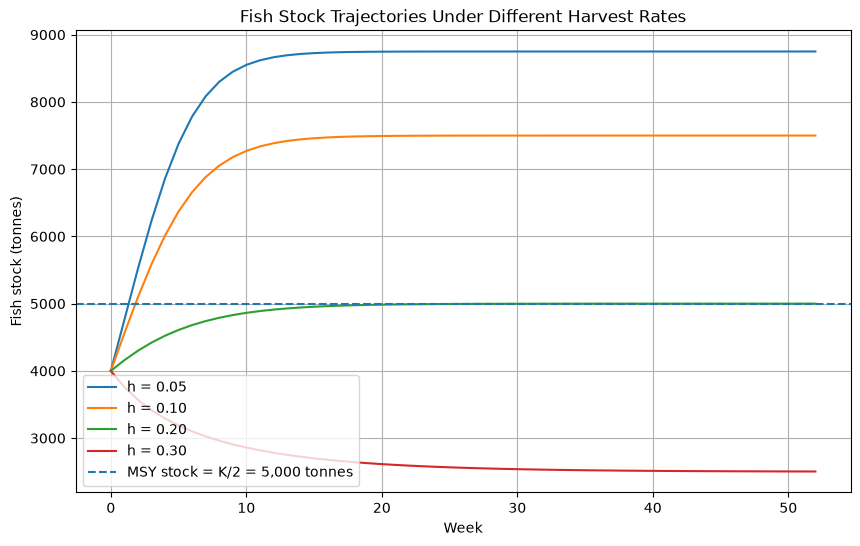

In [15]:
"""Produce (a) stock trajectories for each harvest rate on one chart, and (b) a 
histogram of simulated annual revenue with the VaR marked."""
plt.figure(figsize=(10, 6))
for h in harvest_rates:
    fish = FishStock(h=h)
    stock, harvest = fish.simulate(52)
    plt.plot(range(53),stock,label=f"h = {h:.2f}")
plt.axhline(5000,linestyle="--",label="MSY stock = K/2 = 5,000 tonnes")
plt.title("Fish Stock Trajectories Under Different Harvest Rates")
plt.xlabel("Week")
plt.ylabel("Fish stock (tonnes)")
plt.legend()
plt.grid(True)
plt.show()

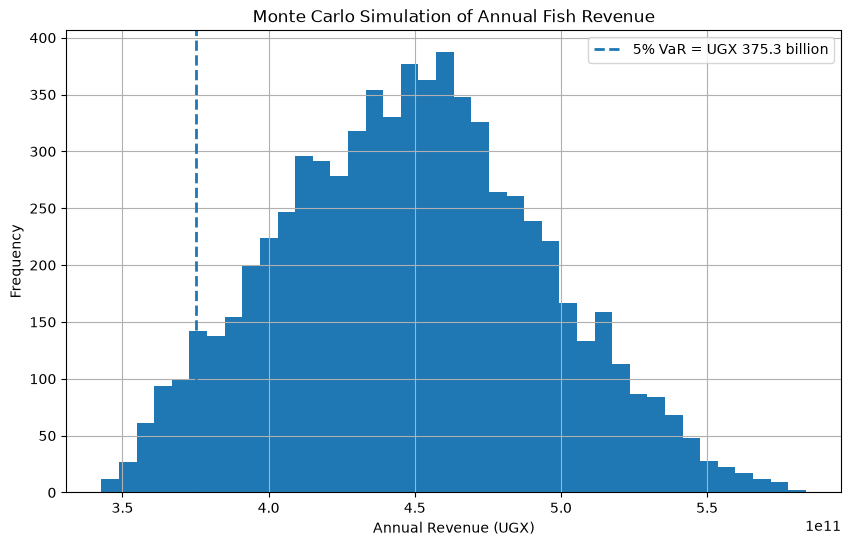

In [16]:
plt.figure(figsize=(10, 6))
plt.hist(annual_revenue,bins=40)
plt.axvline(var_5,linestyle="--",linewidth=2,label=f"5% VaR = UGX {var_5/1e9:.1f} billion")
plt.title("Monte Carlo Simulation of Annual Fish Revenue")
plt.xlabel("Annual Revenue (UGX)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.show()

In [17]:
""" Add a closed season (no harvesting for 8 weeks per year) and quantify its effect on 
long-run revenue over 5 years."""
harvest = 0
def simulate_closed_season(h=0.10,years=5,closed_weeks=8,seed=42):
    total_weeks = years * 52
    price_model = PriceModel(seed=seed)
    prices = price_model.simulate(total_weeks)
    N = 4000
    stock = [N]
    harvest = []
    for week in range(total_weeks):
        week_of_year = week % 52
        if week_of_year < closed_weeks:
            H = 0
        else:
            H = h * N
        harvest.append(H)
        N_next = (N + 0.4 * N * (1 - N / 10000)- H)
        N_next = max(0, N_next)
        stock.append(N_next)
        N = N_next

    stock = np.array(stock)
    harvest = np.array(harvest)
    revenue = harvest * 1000 * prices
    return stock, harvest, prices, revenue

In [17]:
# No closed season
stock_normal, harvest_normal, prices_normal, revenue_normal = (
    simulate_closed_season(h=0.10,years=5,closed_weeks=0,seed=42))
# 8-week closed season
stock_closed, harvest_closed, prices_closed, revenue_closed = (
    simulate_closed_season(h=0.10,years=5,closed_weeks=8,seed=42))

normal_total = revenue_normal.sum()
closed_total = revenue_closed.sum()
difference = closed_total - normal_total
percentage_change = (difference / normal_total) * 100
print("5-year revenue without closed season:",
      normal_total)
print("5-year revenue with 8-week closed season:",
      closed_total)
print("Difference:",
      difference)
print("Percentage change:",
      percentage_change)

5-year revenue without closed season: 2111603866268.3682
5-year revenue with 8-week closed season: 1838748938783.082
Difference: -272854927485.28613
Percentage change: -12.921691035140794
